In [ ]:
# ============================================================
# MAJOR PROJECT
# SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
# ============================================================

print("=" * 70)
print("SEASONAL AGRICULTURE PERFORMANCE ANALYSIS")
print("=" * 70)
print("Data Analytics Project")
print("=" * 70)

SEASONAL AGRICULTURE PERFORMANCE ANALYSIS
Data Analytics Project


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

In [ ]:
from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("File:", file_name)

Saving seasonal_agriculture_performance_dataset.csv to seasonal_agriculture_performance_dataset.csv
Dataset loaded successfully!
File: seasonal_agriculture_performance_dataset.csv


In [ ]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(i, ".", col)

Number of Rows: 4000
Number of Columns: 28

Column Names:
1 . Farm_ID
2 . State
3 . District
4 . Crop
5 . Season
6 . Farm_Area_Hectares
7 . Rainfall_mm
8 . Avg_Temperature_C
9 . Humidity_pct
10 . Sunlight_Hours_Day
11 . Soil_pH
12 . Soil_Moisture_pct
13 . Nitrogen_kg_ha
14 . Phosphorus_kg_ha
15 . Potassium_kg_ha
16 . Irrigation_Method
17 . Fertilizer_kg_ha
18 . Pesticide_Litre_ha
19 . Seed_Quality_Score
20 . Yield_Tonnes_Ha
21 . Production_Tonnes
22 . Market_Price_INR_Tonne
23 . Total_Cost_INR
24 . Revenue_INR
25 . Profit_INR
26 . Water_Used_m3
27 . Water_Efficiency_t_per_1000m3
28 . Disease_Pest_Risk_pct


In [ ]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,4000.00,NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,3952.00,NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [ ]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Column": missing.index,
    "Missing_Values": missing.values,
    "Missing_Percentage": (missing.values / len(df)) * 100
})

missing_df = missing_df.sort_values(
    by="Missing_Values",
    ascending=False
)

missing_df

,Column,Missing_Values,Missing_Percentage
6,Rainfall_mm,48,1.20
11,Soil_Moisture_pct,40,1.00
19,Yield_Tonnes_Ha,32,0.80
0,Farm_ID,0,0.00
3,Crop,0,0.00
2,District,0,0.00
5,Farm_Area_Hectares,0,0.00
4,Season,0,0.00
7,Avg_Temperature_C,0,0.00
8,Humidity_pct,0,0.00


In [ ]:
duplicates = df.duplicated().sum()

print("Duplicate records:", duplicates)

df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Duplicate records: 0
Dataset shape after removing duplicates: (4000, 28)


In [ ]:
print("Numeric Columns:")
print(df.select_dtypes(include=np.number).columns.tolist())

print("\nCategorical Columns:")
print(df.select_dtypes(exclude=np.number).columns.tolist())

Numeric Columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


In [ ]:
print("Seasons:")
print(df["Season"].value_counts())

print("\nCrops:")
print(df["Crop"].value_counts())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crops:
Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

Irrigation Methods:
Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


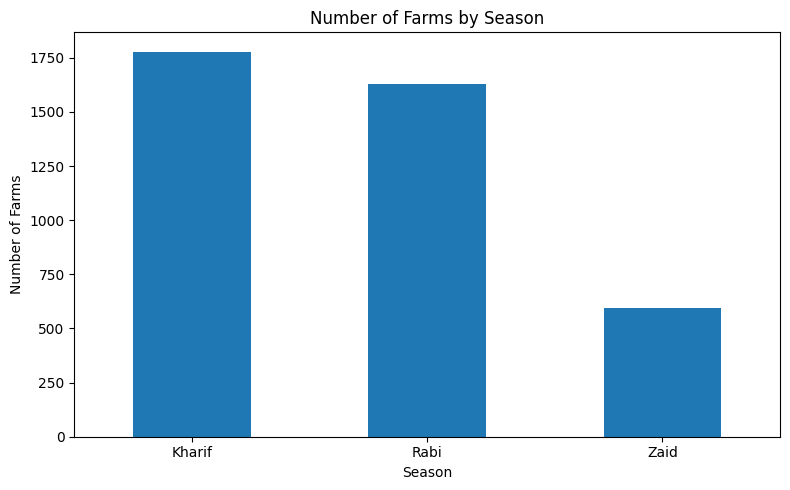

In [ ]:
season_count = df["Season"].value_counts()

plt.figure(figsize=(8,5))
season_count.plot(kind="bar")

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

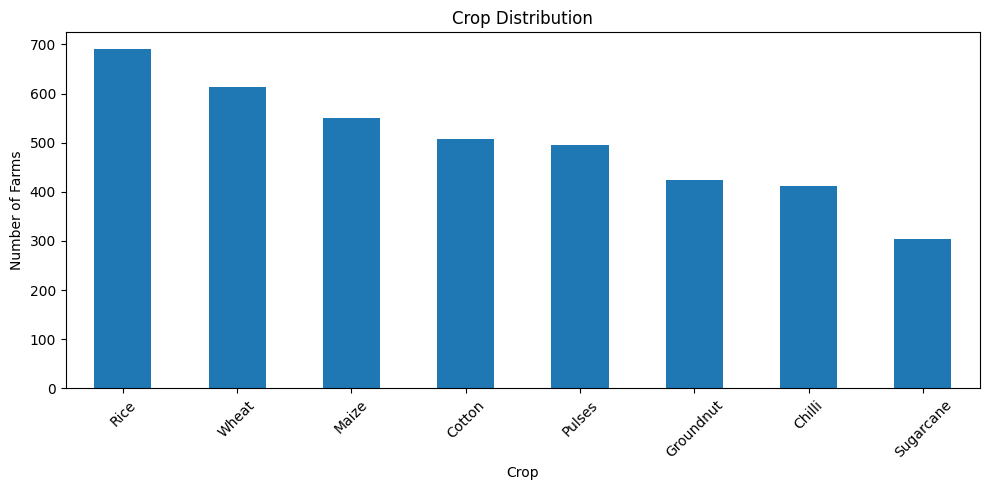

In [ ]:
crop_count = df["Crop"].value_counts()

plt.figure(figsize=(10,5))
crop_count.plot(kind="bar")

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Season
Kharif   5.64
Rabi     5.08
Zaid     4.67
Name: Yield_Tonnes_Ha, dtype: float64


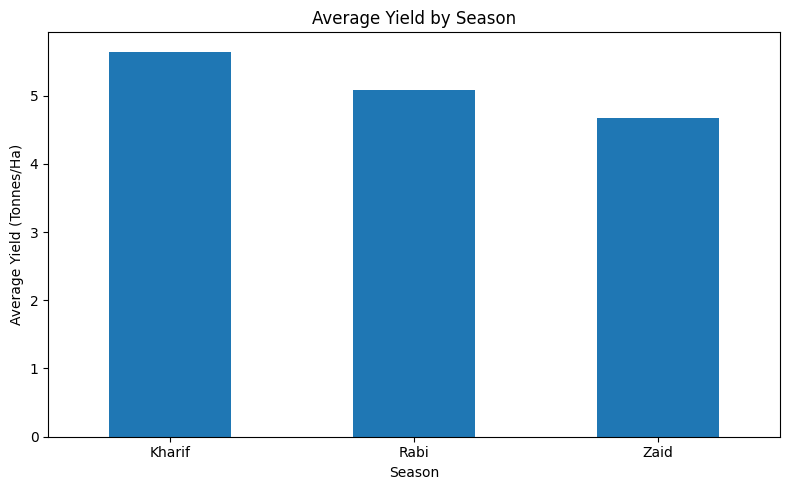

In [ ]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(
    ascending=False
)

print(season_yield)

plt.figure(figsize=(8,5))
season_yield.plot(kind="bar")

plt.title("Average Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   46.31
Rabi     41.49
Zaid     38.89
Name: Production_Tonnes, dtype: float64


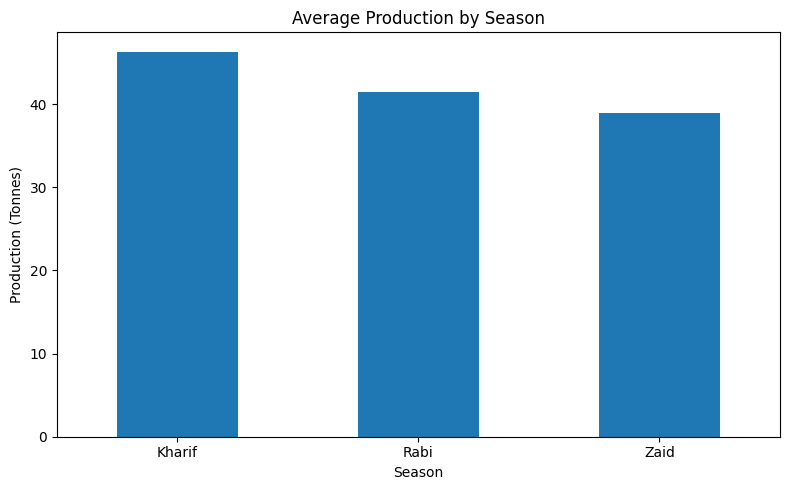

In [ ]:
season_production = df.groupby("Season")["Production_Tonnes"].mean()

print(season_production)

plt.figure(figsize=(8,5))
season_production.plot(kind="bar")

plt.title("Average Production by Season")
plt.xlabel("Season")
plt.ylabel("Production (Tonnes)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   710719.06
Rabi     601526.05
Zaid     519171.90
Name: Revenue_INR, dtype: float64


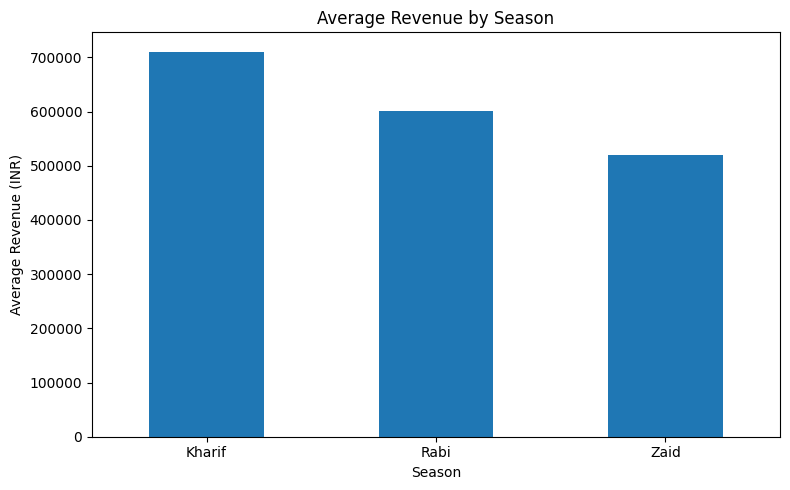

In [ ]:
season_revenue = df.groupby("Season")["Revenue_INR"].mean()

print(season_revenue)

plt.figure(figsize=(8,5))
season_revenue.plot(kind="bar")

plt.title("Average Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Average Revenue (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   178914.65
Rabi      87689.47
Zaid     -24804.82
Name: Profit_INR, dtype: float64


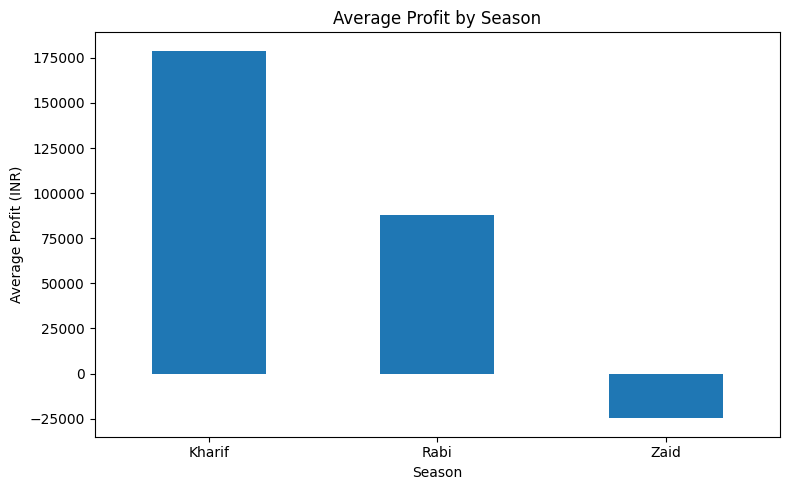

In [ ]:
season_profit = df.groupby("Season")["Profit_INR"].mean()

print(season_profit)

plt.figure(figsize=(8,5))
season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   531804.41
Rabi     513836.58
Zaid     543976.73
Name: Total_Cost_INR, dtype: float64


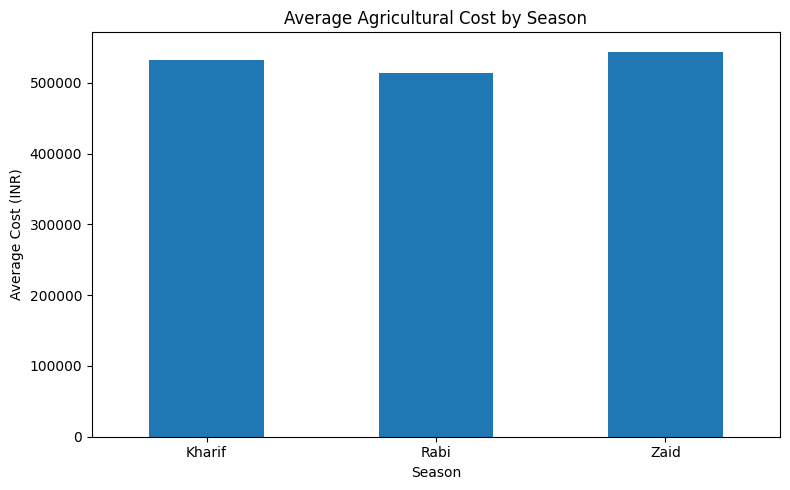

In [ ]:
season_cost = df.groupby("Season")["Total_Cost_INR"].mean()

print(season_cost)

plt.figure(figsize=(8,5))
season_cost.plot(kind="bar")

plt.title("Average Agricultural Cost by Season")
plt.xlabel("Season")
plt.ylabel("Average Cost (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
environmental = df.groupby("Season")[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day",
        "Soil_Moisture_pct"
    ]
].mean()

environmental

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.08,28.45,71.81,6.79,31.20
Rabi,436.00,23.49,57.89,7.59,24.05
Zaid,299.42,31.04,52.01,8.18,19.17


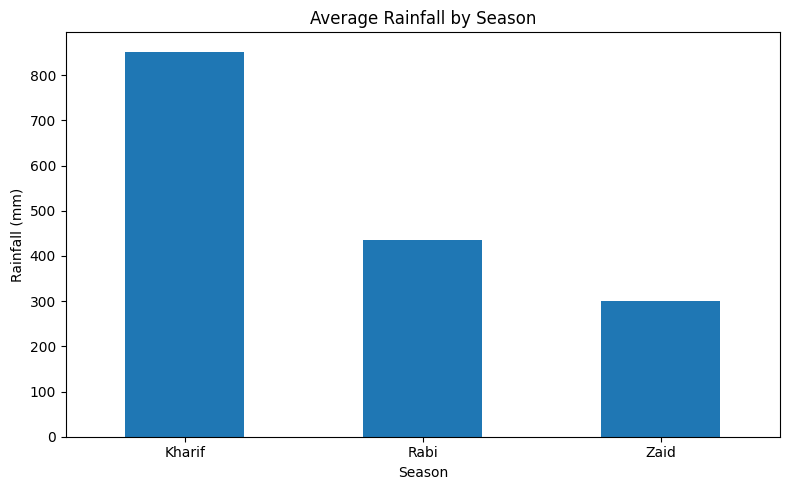

In [ ]:
rainfall = df.groupby("Season")["Rainfall_mm"].mean()

plt.figure(figsize=(8,5))
rainfall.plot(kind="bar")

plt.title("Average Rainfall by Season")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

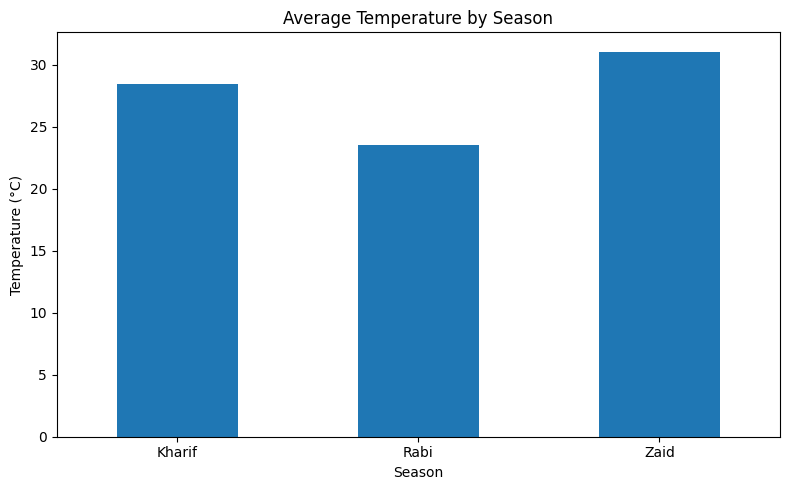

In [ ]:
temperature = df.groupby("Season")["Avg_Temperature_C"].mean()

plt.figure(figsize=(8,5))
temperature.plot(kind="bar")

plt.title("Average Temperature by Season")
plt.xlabel("Season")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

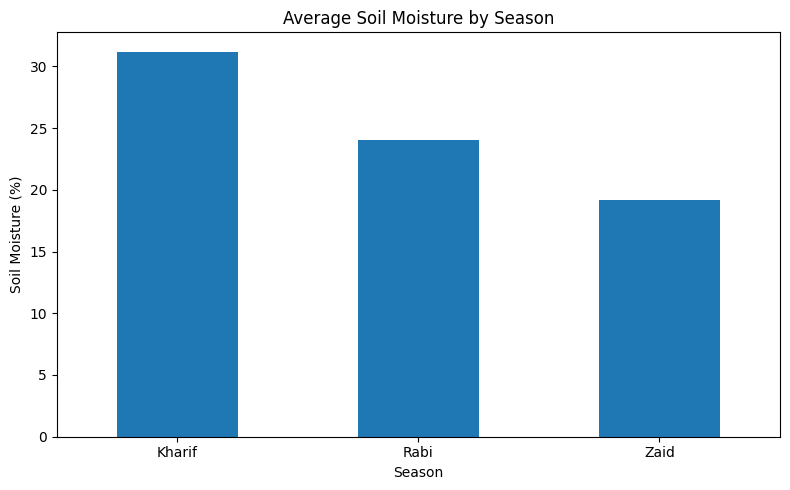

In [ ]:
soil_moisture = df.groupby("Season")["Soil_Moisture_pct"].mean()

plt.figure(figsize=(8,5))
soil_moisture.plot(kind="bar")

plt.title("Average Soil Moisture by Season")
plt.xlabel("Season")
plt.ylabel("Soil Moisture (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   187.08
Rabi     185.41
Zaid     184.64
Name: Fertilizer_kg_ha, dtype: float64


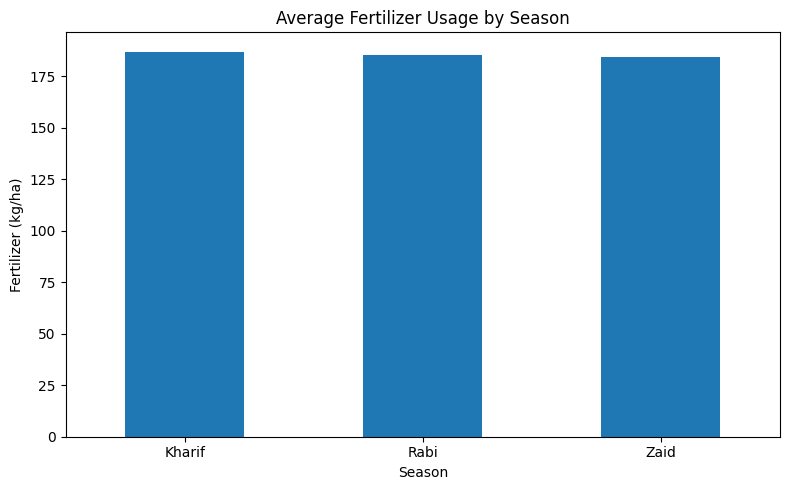

In [ ]:
fertilizer = df.groupby("Season")["Fertilizer_kg_ha"].mean()

print(fertilizer)

plt.figure(figsize=(8,5))
fertilizer.plot(kind="bar")

plt.title("Average Fertilizer Usage by Season")
plt.xlabel("Season")
plt.ylabel("Fertilizer (kg/ha)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   6102.20
Rabi     5846.99
Zaid     6419.89
Name: Water_Used_m3, dtype: float64


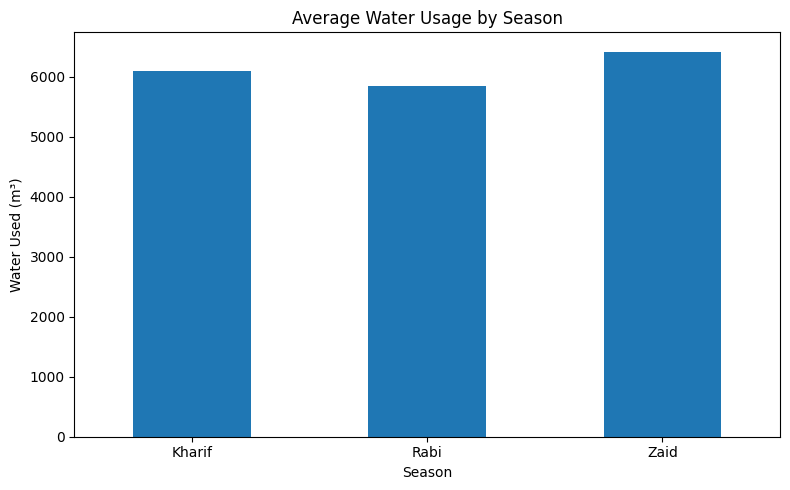

In [ ]:
water = df.groupby("Season")["Water_Used_m3"].mean()

print(water)

plt.figure(figsize=(8,5))
water.plot(kind="bar")

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Season
Kharif   5.89
Rabi     5.19
Zaid     4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


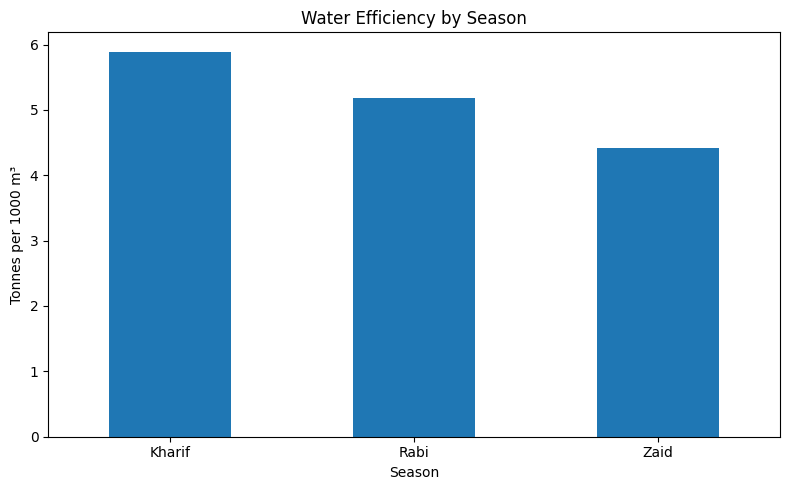

In [ ]:
water_efficiency = df.groupby("Season")[
    "Water_Efficiency_t_per_1000m3"
].mean().sort_values(ascending=False)

print(water_efficiency)

plt.figure(figsize=(8,5))
water_efficiency.plot(kind="bar")

plt.title("Water Efficiency by Season")
plt.xlabel("Season")
plt.ylabel("Tonnes per 1000 m³")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Crop
Sugarcane   46.94
Maize        2.72
Rice         2.44
Wheat        2.11
Chilli       1.54
Groundnut    1.32
Cotton       1.23
Pulses       0.92
Name: Yield_Tonnes_Ha, dtype: float64


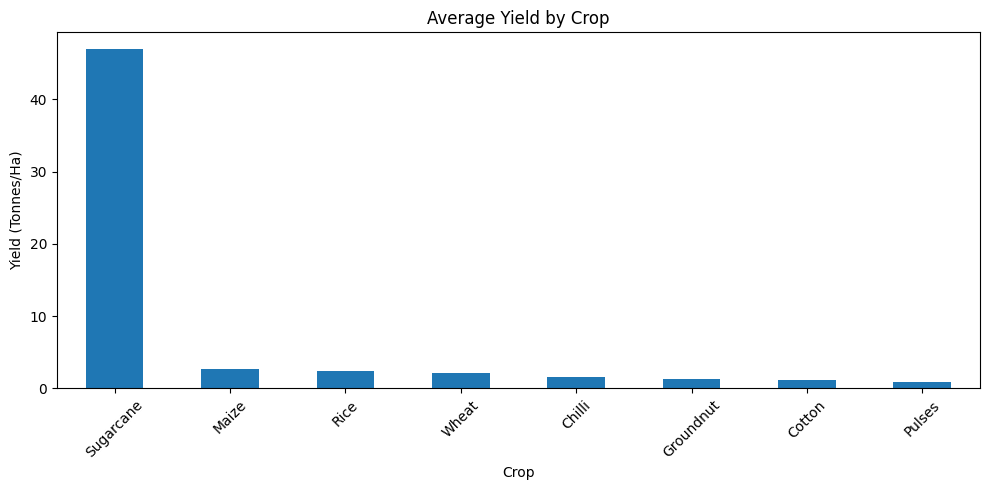

In [ ]:
crop_yield = df.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(
    ascending=False
)

print(crop_yield)

plt.figure(figsize=(10,5))
crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
crop_season_yield = pd.pivot_table(
    df,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.46,1.18
Cotton,1.37,1.19,0.95
Groundnut,1.48,1.22,1.04
Maize,2.97,2.61,2.30
Pulses,1.04,0.87,0.65
Rice,2.71,2.33,1.90
Sugarcane,53.46,43.94,38.42
Wheat,2.26,2.06,1.75


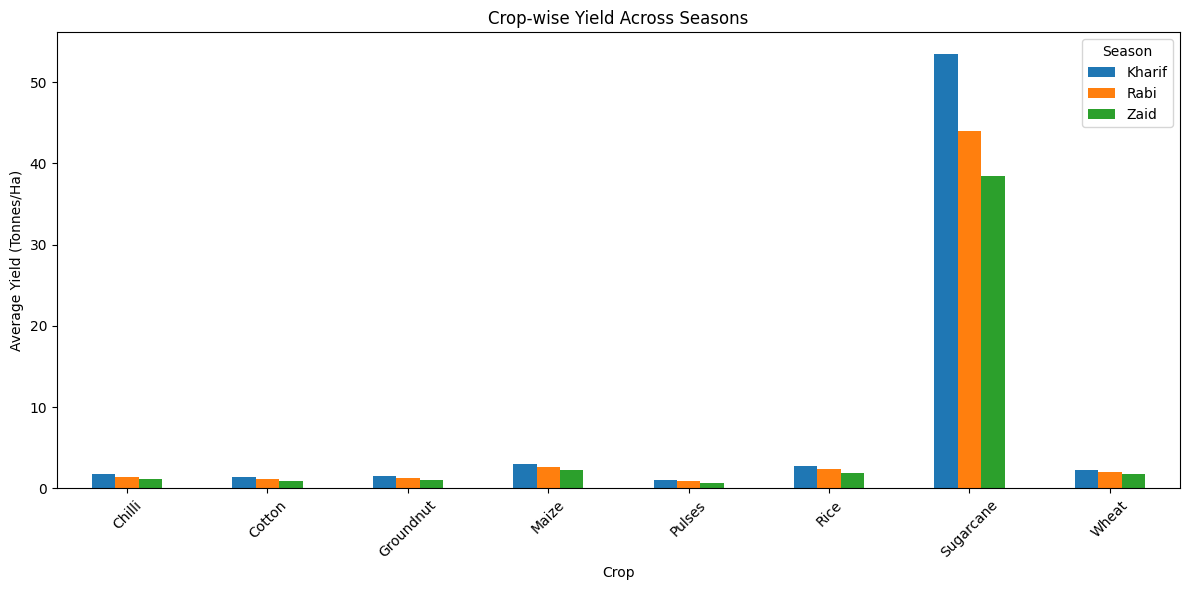

In [ ]:
crop_season_yield.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Crop-wise Yield Across Seasons")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64


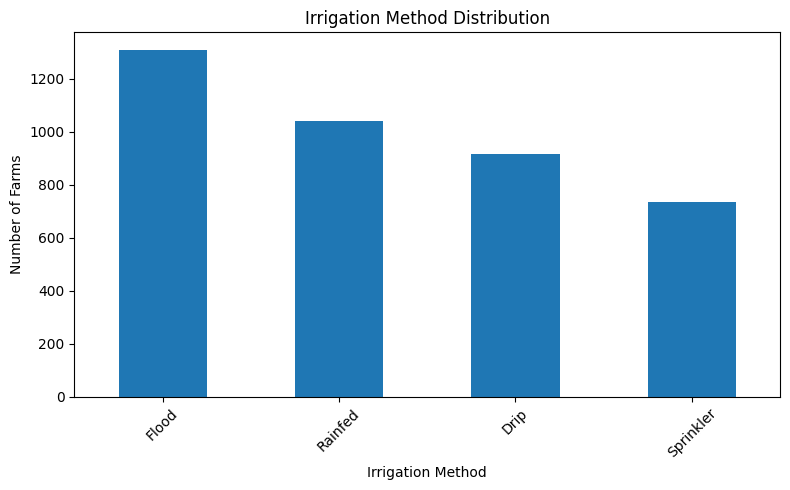

In [ ]:
irrigation_count = df["Irrigation_Method"].value_counts()

print(irrigation_count)

plt.figure(figsize=(8,5))
irrigation_count.plot(kind="bar")

plt.title("Irrigation Method Distribution")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Irrigation_Method
Drip        6.62
Sprinkler   5.19
Flood       4.90
Rainfed     4.61
Name: Yield_Tonnes_Ha, dtype: float64


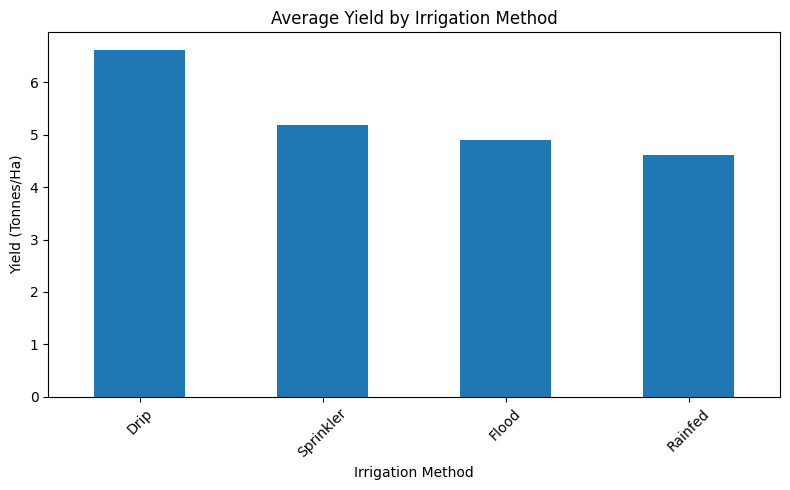

In [ ]:
irrigation_yield = df.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

print(irrigation_yield)

plt.figure(figsize=(8,5))
irrigation_yield.plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Irrigation_Method
Rainfed     7.56
Drip        6.27
Sprinkler   4.67
Flood       3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64


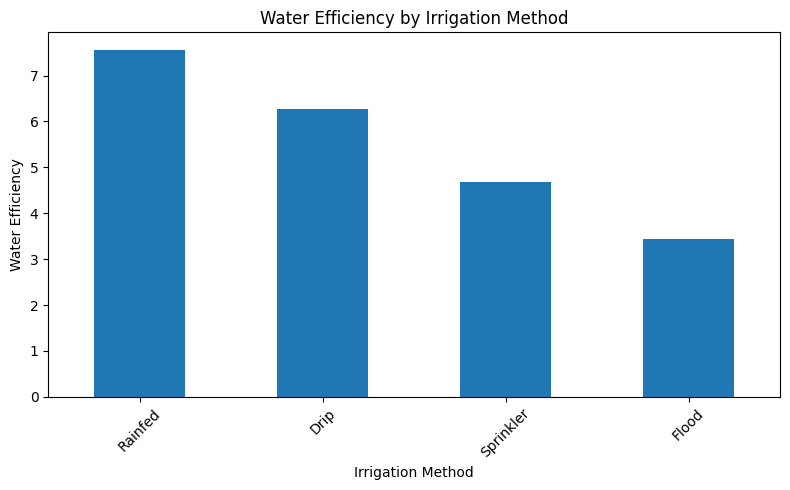

In [ ]:
irrigation_efficiency = df.groupby(
    "Irrigation_Method"
)["Water_Efficiency_t_per_1000m3"].mean().sort_values(
    ascending=False
)

print(irrigation_efficiency)

plt.figure(figsize=(8,5))
irrigation_efficiency.plot(kind="bar")

plt.title("Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
best_profit_season = season_profit.idxmax()
best_profit_value = season_profit.max()

print("Most profitable season:", best_profit_season)
print("Average profit:", round(best_profit_value, 2))

Most profitable season: Kharif
Average profit: 178914.65


In [ ]:
best_yield_season = season_yield.idxmax()
best_yield_value = season_yield.max()

print("Highest yielding season:", best_yield_season)
print("Average yield:", round(best_yield_value, 2), "Tonnes/Ha")

Highest yielding season: Kharif
Average yield: 5.64 Tonnes/Ha


In [ ]:
best_water_season = water_efficiency.idxmax()
best_water_value = water_efficiency.max()

print("Most water-efficient season:", best_water_season)
print("Water efficiency:", round(best_water_value, 3))

Most water-efficient season: Kharif
Water efficiency: 5.892


In [ ]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()

correlation.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.52,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.63
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.52,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


In [ ]:
yield_corr = correlation["Yield_Tonnes_Ha"].sort_values(
    ascending=False
)

print("Correlation with Yield:")
print(yield_corr)

Correlation with Yield:
Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.92
Production_Tonnes                0.89
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Farm_Area_Hectares               0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64


In [ ]:
profit_corr = correlation["Profit_INR"].sort_values(
    ascending=False
)

print("Correlation with Profit:")
print(profit_corr)

Correlation with Profit:
Profit_INR                       1.00
Revenue_INR                      0.89
Production_Tonnes                0.55
Yield_Tonnes_Ha                  0.49
Water_Efficiency_t_per_1000m3    0.49
Market_Price_INR_Tonne           0.23
Water_Used_m3                    0.19
Farm_Area_Hectares               0.12
Rainfall_mm                      0.11
Soil_Moisture_pct                0.09
Nitrogen_kg_ha                   0.09
Total_Cost_INR                   0.07
Disease_Pest_Risk_pct            0.07
Humidity_pct                     0.06
Phosphorus_kg_ha                 0.05
Potassium_kg_ha                  0.03
Seed_Quality_Score               0.01
Avg_Temperature_C                0.01
Soil_pH                         -0.01
Pesticide_Litre_ha              -0.03
Sunlight_Hours_Day              -0.05
Fertilizer_kg_ha                -0.07
Name: Profit_INR, dtype: float64


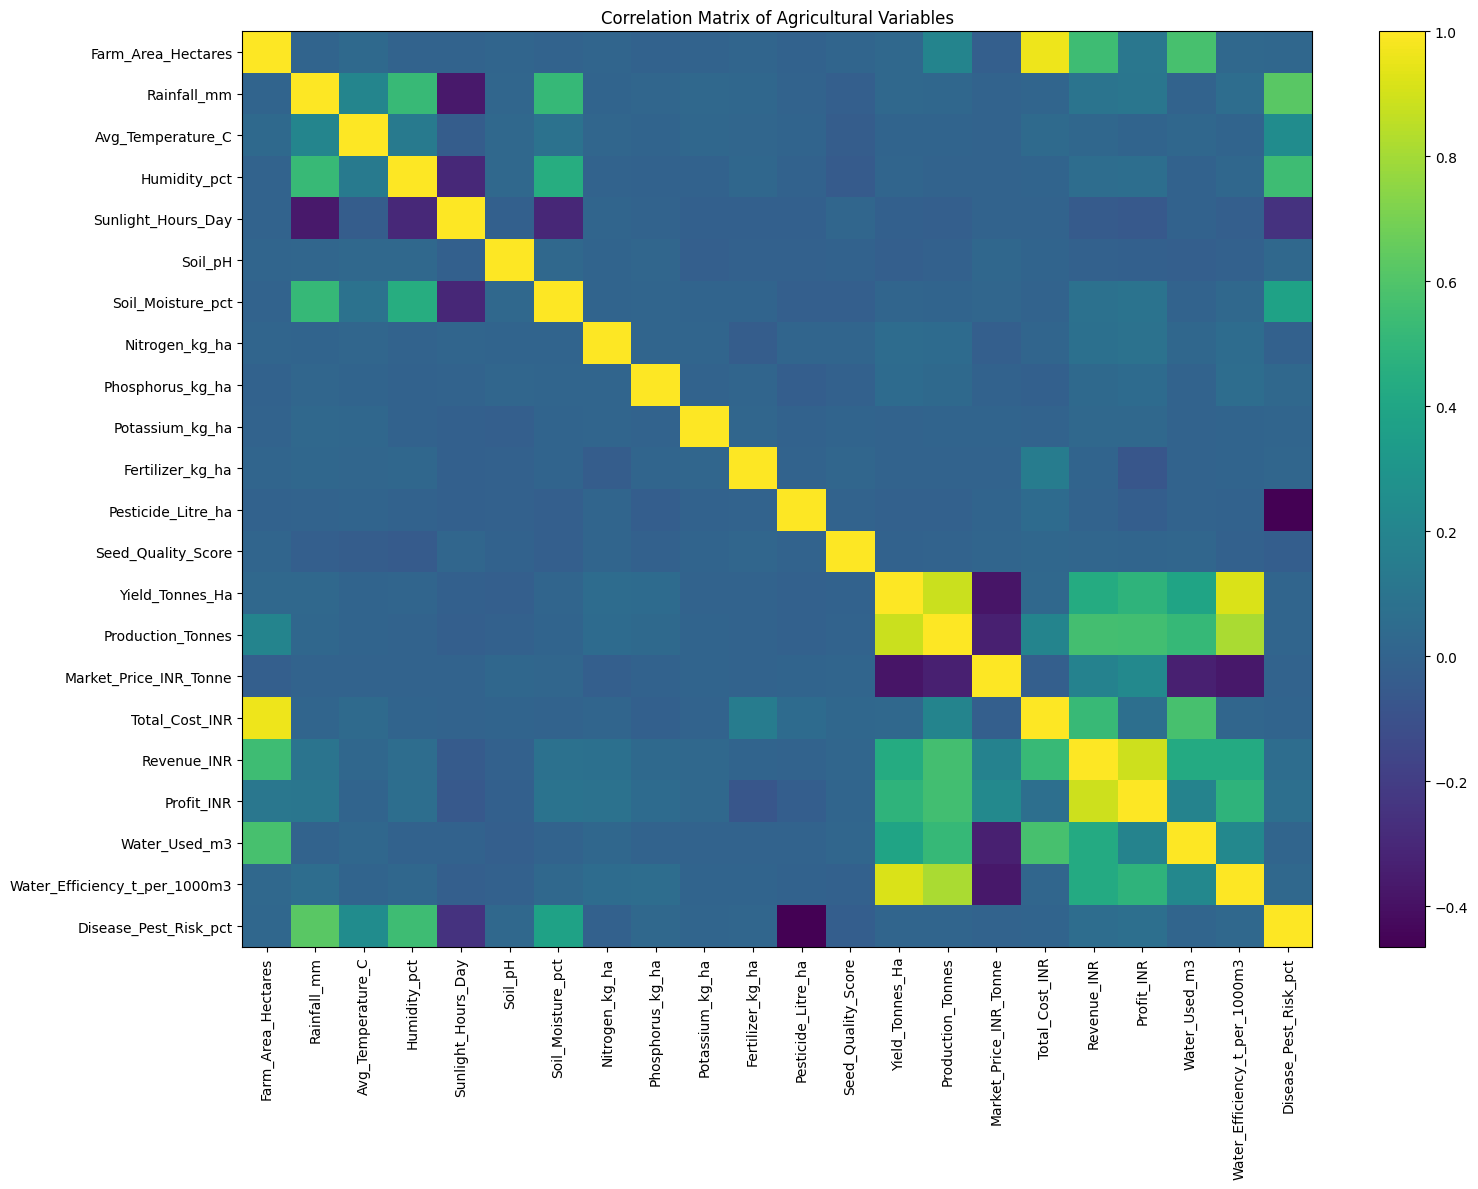

In [ ]:
plt.figure(figsize=(16,12))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix of Agricultural Variables")

plt.tight_layout()
plt.show()

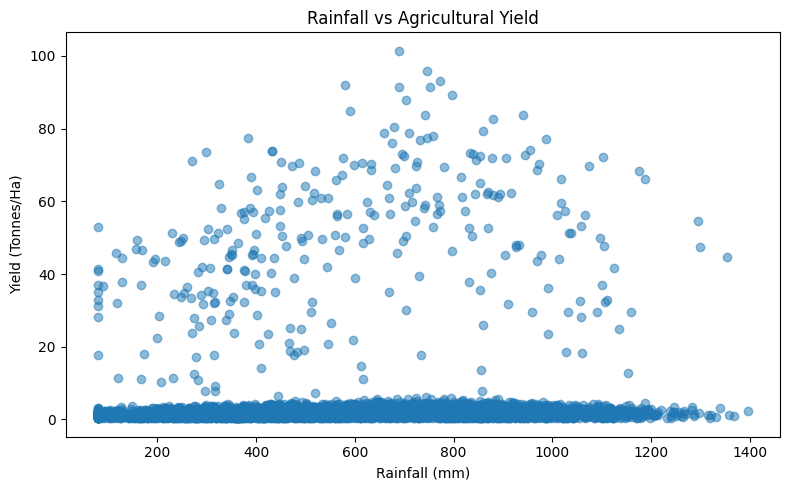

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Rainfall_mm"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

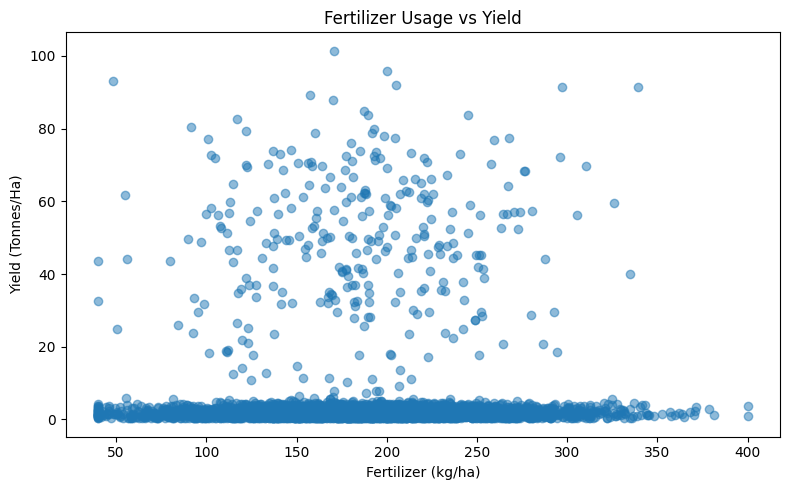

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Fertilizer_kg_ha"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Fertilizer Usage vs Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

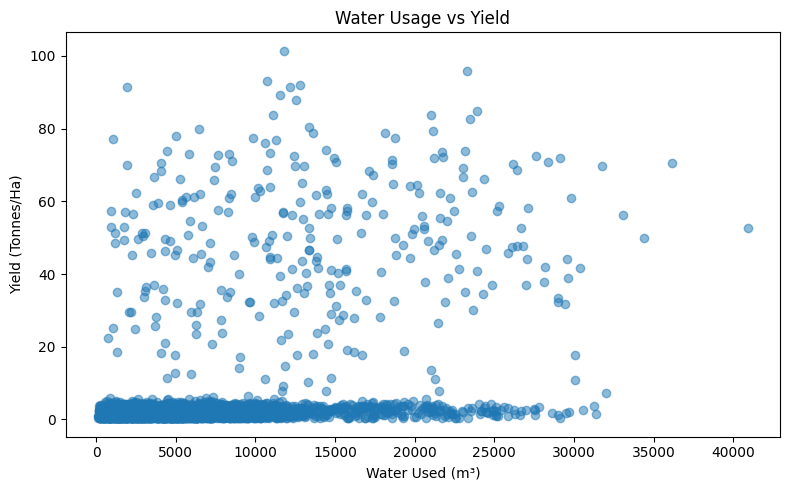

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Water_Used_m3"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Water Usage vs Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

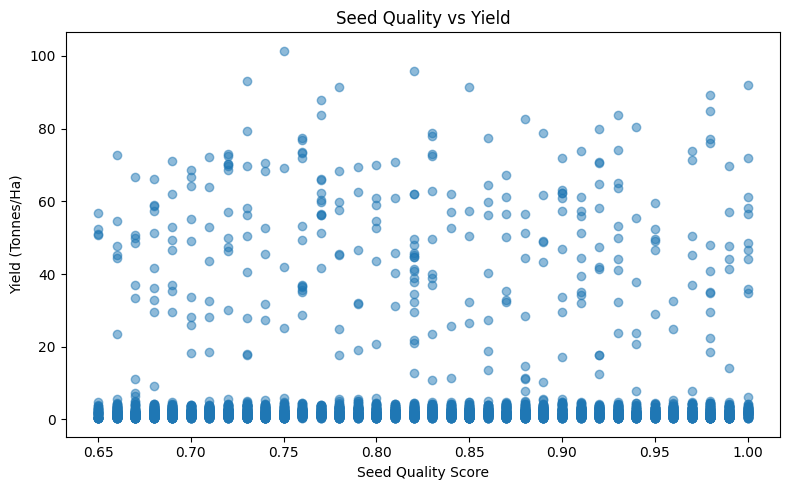

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Seed_Quality_Score"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Seed Quality vs Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [ ]:
season_groups = [
    group["Yield_Tonnes_Ha"].values
    for name, group in df.groupby("Season")
]

anova_result = stats.f_oneway(*season_groups)

print("ANOVA Test for Yield Across Seasons")
print("------------------------------------")
print("F-statistic:", round(anova_result.statistic, 4))
print("P-value:", round(anova_result.pvalue, 6))

if anova_result.pvalue < 0.05:
    print("\nResult: There is a statistically significant difference")
    print("in average yield among seasons.")
else:
    print("\nResult: No statistically significant difference")
    print("in average yield among seasons.")

ANOVA Test for Yield Across Seasons
------------------------------------
F-statistic: nan
P-value: nan

Result: No statistically significant difference
in average yield among seasons.


In [ ]:
profit_groups = [
    group["Profit_INR"].values
    for name, group in df.groupby("Season")
]

profit_anova = stats.f_oneway(*profit_groups)

print("ANOVA Test for Profit Across Seasons")
print("------------------------------------")
print("F-statistic:", round(profit_anova.statistic, 4))
print("P-value:", round(profit_anova.pvalue, 6))

if profit_anova.pvalue < 0.05:
    print("\nResult: Profit differs significantly across seasons.")
else:
    print("\nResult: Profit does not differ significantly across seasons.")

ANOVA Test for Profit Across Seasons
------------------------------------
F-statistic: 34.2918
P-value: 0.0

Result: Profit differs significantly across seasons.


In [ ]:
state_yield = df.groupby("State")[
    "Yield_Tonnes_Ha"
].mean().sort_values(ascending=False)

print(state_yield)

State
Punjab           6.12
Karnataka        5.73
Gujarat          5.70
Telangana        5.08
Maharashtra      5.03
Madhya Pradesh   5.03
Tamil Nadu       4.90
Andhra Pradesh   4.65
Name: Yield_Tonnes_Ha, dtype: float64


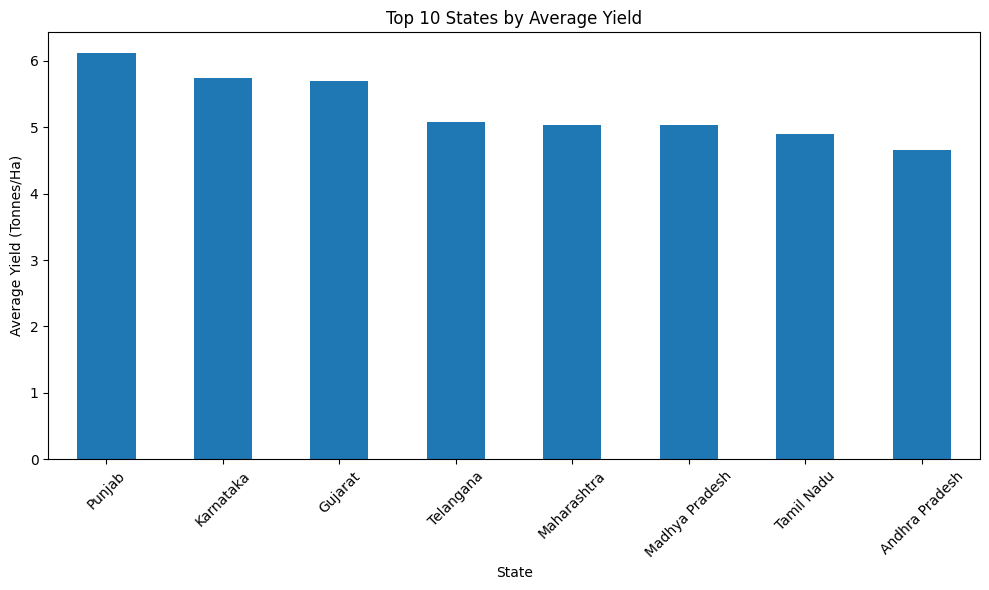

In [ ]:
top_states = state_yield.head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind="bar")

plt.title("Top 10 States by Average Yield")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
state_profit = df.groupby("State")[
    "Profit_INR"
].mean().sort_values(ascending=False)

print("Top 10 states by average profit:")
print(state_profit.head(10))

Top 10 states by average profit:
State
Punjab           136025.64
Maharashtra      135428.86
Karnataka        119422.34
Tamil Nadu       117744.75
Gujarat          117568.24
Telangana        108829.62
Madhya Pradesh    86840.76
Andhra Pradesh    73453.53
Name: Profit_INR, dtype: float64


Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64


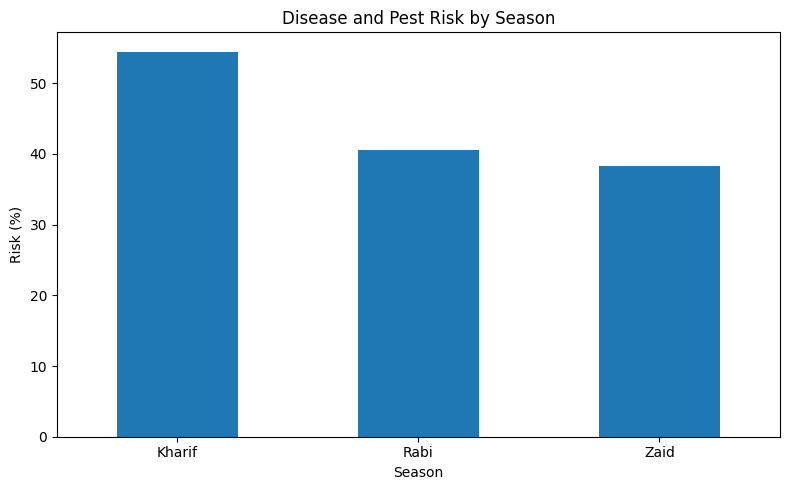

In [ ]:
risk_season = df.groupby("Season")[
    "Disease_Pest_Risk_pct"
].mean().sort_values(ascending=False)

print(risk_season)

plt.figure(figsize=(8,5))
risk_season.plot(kind="bar")

plt.title("Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

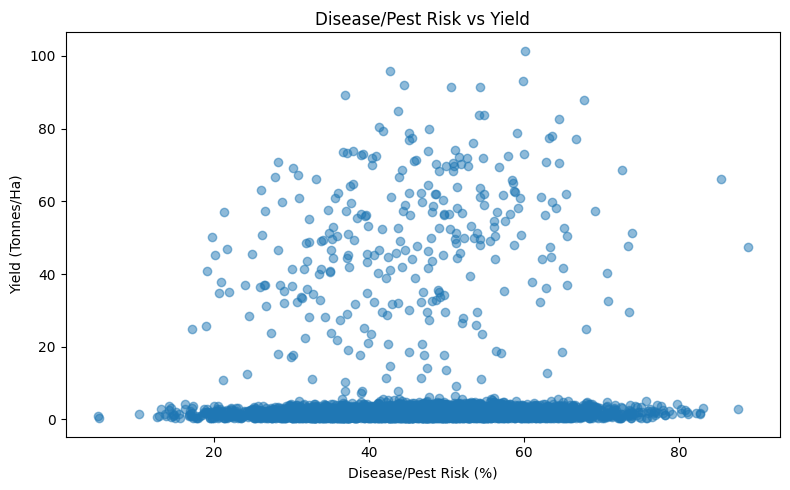

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Disease_Pest_Risk_pct"],
    df["Yield_Tonnes_Ha"],
    alpha=0.5
)

plt.title("Disease/Pest Risk vs Yield")
plt.xlabel("Disease/Pest Risk (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("KEY FINDINGS")
print("=" * 70)

print("\n1. Highest Average Yield Season")
print("--------------------------------")
print(best_yield_season)
print("Average Yield:", round(best_yield_value, 2), "Tonnes/Ha")

print("\n2. Most Profitable Season")
print("-------------------------")
print(best_profit_season)
print("Average Profit: ₹", round(best_profit_value, 2))

print("\n3. Most Water-Efficient Season")
print("------------------------------")
print(best_water_season)
print("Water Efficiency:", round(best_water_value, 3))

print("\n4. Highest Average Yield Crop")
print("-----------------------------")
best_crop = crop_yield.idxmax()
print(best_crop)
print("Average Yield:", round(crop_yield.max(), 2), "Tonnes/Ha")

print("\n5. Best Irrigation Method for Yield")
print("-----------------------------------")
best_irrigation = irrigation_yield.idxmax()
print(best_irrigation)
print("Average Yield:", round(irrigation_yield.max(), 2), "Tonnes/Ha")

print("\n6. Best Irrigation Method for Water Efficiency")
print("----------------------------------------------")
best_irrigation_eff = irrigation_efficiency.idxmax()
print(best_irrigation_eff)
print("Efficiency:", round(irrigation_efficiency.max(), 3))

print("\n7. ANOVA Yield P-value")
print("----------------------")
print(round(anova_result.pvalue, 6))

KEY FINDINGS

1. Highest Average Yield Season
--------------------------------
Kharif
Average Yield: 5.64 Tonnes/Ha

2. Most Profitable Season
-------------------------
Kharif
Average Profit: ₹ 178914.65

3. Most Water-Efficient Season
------------------------------
Kharif
Water Efficiency: 5.892

4. Highest Average Yield Crop
-----------------------------
Sugarcane
Average Yield: 46.94 Tonnes/Ha

5. Best Irrigation Method for Yield
-----------------------------------
Drip
Average Yield: 6.62 Tonnes/Ha

6. Best Irrigation Method for Water Efficiency
----------------------------------------------
Rainfed
Efficiency: 7.564

7. ANOVA Yield P-value
----------------------
nan


In [ ]:
season_summary = df.groupby("Season").agg({
    "Farm_ID": "count",
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "mean",
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean",
    "Profit_INR": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Disease_Pest_Risk_pct": "mean"
})

season_summary = season_summary.rename(
    columns={"Farm_ID": "Number_of_Farms"}
)

season_summary.round(2)

,Number_of_Farms,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,,,
Kharif,1779,5.64,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,1627,5.08,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,594,4.67,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


In [ ]:
print("=" * 70)
print("DATA-DRIVEN RECOMMENDATIONS")
print("=" * 70)

print("""
1. Seasonal Planning
   Farmers should consider seasonal differences in yield, profitability,
   environmental conditions and resource requirements while planning crops.

2. Water Management
   Water-efficient irrigation methods should be considered where they
   provide better water efficiency without reducing productivity.

3. Crop Selection
   Crop performance should be compared across seasons and regions before
   selecting crops for cultivation.

4. Resource Optimization
   Fertilizer, pesticide and irrigation usage should be monitored carefully
   to avoid unnecessary resource consumption.

5. Environmental Monitoring
   Rainfall, temperature, humidity and soil moisture should be monitored
   because environmental conditions can influence agricultural outcomes.

6. Disease and Pest Management
   Seasons with higher disease/pest risk require better monitoring and
   preventive agricultural practices.

7. Profit-Based Planning
   Crop and season selection should consider both yield and economic
   performance rather than yield alone.

8. Evidence-Based Decisions
   Historical agricultural data can be used to identify seasonal patterns
   and support better agricultural planning.
""")

DATA-DRIVEN RECOMMENDATIONS

1. Seasonal Planning
   Farmers should consider seasonal differences in yield, profitability,
   environmental conditions and resource requirements while planning crops.

2. Water Management
   Water-efficient irrigation methods should be considered where they
   provide better water efficiency without reducing productivity.

3. Crop Selection
   Crop performance should be compared across seasons and regions before
   selecting crops for cultivation.

4. Resource Optimization
   Fertilizer, pesticide and irrigation usage should be monitored carefully
   to avoid unnecessary resource consumption.

5. Environmental Monitoring
   Rainfall, temperature, humidity and soil moisture should be monitored
   because environmental conditions can influence agricultural outcomes.

6. Disease and Pest Management
   Seasons with higher disease/pest risk require better monitoring and
   preventive agricultural practices.

7. Profit-Based Planning
   Crop and season selecti

In [ ]:
print("=" * 70)
print("PROJECT CONCLUSION")
print("=" * 70)

print(f"""
The Seasonal Agriculture Performance Analysis examined {len(df):,} agricultural
records across different seasons, crops, regions, environmental conditions
and farming practices.

The analysis compared agricultural performance using indicators such as
yield, production, revenue, cost, profit and water efficiency.

The analysis also examined relationships between agricultural outcomes and
environmental factors, resource usage, irrigation methods, crop selection
and disease/pest risk.

The seasonal comparison helps identify differences in agricultural
performance and provides evidence that can support seasonal planning,
resource management and crop selection.

The statistical analysis was also used to determine whether observed
differences in yield and profitability across seasons were statistically
significant.

Overall, the project demonstrates how data analytics and visualization can
be applied to agricultural data to discover meaningful seasonal patterns
and generate data-driven recommendations.
""")

PROJECT CONCLUSION

The Seasonal Agriculture Performance Analysis examined 4,000 agricultural
records across different seasons, crops, regions, environmental conditions
and farming practices.

The analysis compared agricultural performance using indicators such as
yield, production, revenue, cost, profit and water efficiency.

The analysis also examined relationships between agricultural outcomes and
environmental factors, resource usage, irrigation methods, crop selection
and disease/pest risk.

The seasonal comparison helps identify differences in agricultural
performance and provides evidence that can support seasonal planning,
resource management and crop selection.

The statistical analysis was also used to determine whether observed
differences in yield and profitability across seasons were statistically
significant.

Overall, the project demonstrates how data analytics and visualization can
be applied to agricultural data to discover meaningful seasonal patterns
and generate dat

In [ ]:
df.to_csv(
    "cleaned_seasonal_agriculture_dataset.csv",
    index=False
)

season_summary.to_csv(
    "seasonal_summary.csv"
)

print("Files saved successfully.")

Files saved successfully.


In [ ]:
from google.colab import files

files.download("cleaned_seasonal_agriculture_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>